# Optimasi Rute Pengangkutan Sampah Menggunakan Google OR-Tools (Capacitated VRP)

## Apa itu Vehicle Routing Problem (VRP)?
Vehicle Routing Problem (VRP) adalah permasalahan optimasi kombinatorial untuk menemukan serangkaian rute kendaraan yang paling efisien dalam melayani sejumlah titik (nodus) dari satu atau beberapa depot, dengan memperhatikan batasan tertentu seperti kapasitas kendaraan (*Capacitated VRP / CVRP*).

## Penerapan pada Pengangkutan Sampah
Dalam konteks pengelolaan sampah kota (misal: Kota Surabaya):
* **Depot**: Tempat Pembuangan Akhir (TPA) atau depo armada truk sampah.
* **Nodes**: Tempat Penampungan Sementara (TPS) atau titik pengumpulan.
* **Demand**: Volume/berat sampah di setiap TPS (ton atau $m^3$).
* **Kapasitas**: Batas muatan maksimum truk sampah.

Tujuan utama optimasi ini adalah meminimalkan total jarak tempuh, menghemat konsumsi bahan bakar, serta menyeimbangkan beban kerja armada.


In [1]:
# Cell 1: Install & Import Library
!pip install ortools folium numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


## 1. Penyiapan Data VRP Sederhana
Kita mendefinisikan 1 Depot utama dan 10 lokasi TPS di area Surabaya beserta estimasi *demand* (muatan sampah dalam ton) dan kapasitas maksimum per truk.

In [2]:
# Cell 2: Membuat Dataset (Koordinat Surabaya)
locations = {
    0: (-7.2575, 112.7521),  # Depot (Pusat Kota Surabaya)
    1: (-7.2450, 112.7380),  # TPS 1 (Krembangan)
    2: (-7.2680, 112.7400),  # TPS 2 (Tegalsari)
    3: (-7.2850, 112.7580),  # TPS 3 (Gubeng)
    4: (-7.2920, 112.7350),  # TPS 4 (Wonokromo)
    5: (-7.2700, 112.7800),  # TPS 5 (Sukolilo)
    6: (-7.2300, 112.7600),  # TPS 6 (Pabean Cantian)
    7: (-7.3100, 112.7500),  # TPS 7 (Wonocolo)
    8: (-7.2600, 112.7100),  # TPS 8 (Tandes)
    9: (-7.2800, 112.7200),  # TPS 9 (Sawahan)
    10: (-7.2200, 112.7300)  # TPS 10 (Semampir)
}

# Demand (beban sampah) untuk setiap node (Depot demand = 0)
demands = [0, 8, 12, 15, 10, 18, 9, 14, 11, 13, 7]  # Total: 117 ton

# Konfigurasi Armada
num_vehicles = 3
vehicle_capacity = 45  # Kapasitas tiap truk (ton)

print(f"Jumlah Titik TPS : {len(locations) - 1}")
print(f"Total Demand     : {sum(demands)} ton")
print(f"Total Kapasitas  : {num_vehicles * vehicle_capacity} ton ({num_vehicles} truk @ {vehicle_capacity} ton)")

Jumlah Titik TPS : 10
Total Demand     : 117 ton
Total Kapasitas  : 135 ton (3 truk @ 45 ton)


## 2. Penghitungan Matrix Jarak (Distance Matrix)
Menghitung jarak *Haversine* (dalam meter) antar seluruh pasangan koordinat latitude/longitude.

In [3]:
# Cell 3: Menghitung Distance Matrix (Jarak Haversine)
def haversine_distance(coord1, coord2):
    R = 6371000  # Radius bumi dalam meter
    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return int(R * c)

def compute_distance_matrix(locs):
    n = len(locs)
    matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            matrix[i][j] = haversine_distance(locs[i], locs[j])
    return matrix

distance_matrix = compute_distance_matrix(locations)
print(f"Ukuran Distance Matrix: {distance_matrix.shape}")
print("Contoh Sub-matrix 5x5 (dalam meter):\n", distance_matrix[:5, :5])

Ukuran Distance Matrix: (11, 11)
Contoh Sub-matrix 5x5 (dalam meter):
 [[   0 2085 1773 3126 4274]
 [2085    0 2566 4964 5236]
 [1773 2566    0 2741 2725]
 [3126 4964 2741    0 2653]
 [4274 5236 2725 2653    0]]


## 3. Formulasi & Pemecahan VRP Menggunakan Google OR-Tools
Membangun *routing model*, menambahkan batasan kapasitas kendaraan (*Capacity Constraint*), dan menyelesaikan masalah pencarian rute terbaik.

In [4]:
# Cell 4: Setup & Solve VRP
def create_data_model():
    data = {}
    data['distance_matrix'] = distance_matrix.tolist()
    data['demands'] = demands
    data['vehicle_capacities'] = [vehicle_capacity] * num_vehicles
    data['num_vehicles'] = num_vehicles
    data['depot'] = 0
    return data

def solve_vrp():
    data = create_data_model()

    # Inisialisasi Index Manager & Routing Model
    manager = pywrapcp.RoutingIndexManager(
        len(data['distance_matrix']),
        data['num_vehicles'],
        data['depot']
    )
    routing = pywrapcp.RoutingModel(manager)

    # Callback Jarak
    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Callback Demand & Batasan Kapasitas
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data['demands'][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        data['vehicle_capacities'],
        True,  # start at zero
        'Capacity'
    )

    # Parameter Pencarian Solusi
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    # Solve
    solution = routing.SolveWithParameters(search_parameters)
    return data, manager, routing, solution

data, manager, routing, solution = solve_vrp()
print("Solusi berhasil ditemukan!" if solution else "Gagal menemukan solusi.")

Solusi berhasil ditemukan!


## 4. Ekstraksi Hasil Solusi
Mengambil rute, total jarak, dan muatan dari setiap kendaraan.

In [5]:
# Cell 5: Ekstrak Hasil
def extract_routes(data, manager, routing, solution):
    total_distance = 0
    total_load = 0
    routes_data = []

    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route = []
        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_load += data['demands'][node_index]
            route.append(node_index)
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        node_index = manager.IndexToNode(index)
        route.append(node_index)

        total_distance += route_distance
        total_load += route_load

        routes_data.append({
            'vehicle': vehicle_id,
            'route': route,
            'distance_km': route_distance / 1000.0,
            'load': route_load
        })

        print(f"Truk {vehicle_id + 1}:")
        print(f"  Rute      : {' -> '.join(map(str, route))}")
        print(f"  Muatan    : {route_load}/{data['vehicle_capacities'][vehicle_id]} ton")
        print(f"  Jarak     : {route_distance / 1000.0:.2f} km\n")

    print(f"Total Jarak Seluruh Truk : {total_distance / 1000.0:.2f} km")
    print(f"Total Sampah Diangkut    : {total_load} ton")
    return routes_data

routes_summary = extract_routes(data, manager, routing, solution)

Truk 1:
  Rute      : 0 -> 2 -> 9 -> 8 -> 0
  Muatan    : 36/45 ton
  Jarak     : 11.48 km

Truk 2:
  Rute      : 0 -> 4 -> 7 -> 3 -> 0
  Muatan    : 39/45 ton
  Jarak     : 12.91 km

Truk 3:
  Rute      : 0 -> 5 -> 6 -> 10 -> 1 -> 0
  Muatan    : 42/45 ton
  Jarak     : 16.83 km

Total Jarak Seluruh Truk : 41.23 km
Total Sampah Diangkut    : 117 ton


## 5. Visualisasi Rute (Matplotlib - 2D Plot)
Visualisasi berbasis skema koordinat 2D untuk analisis visual cepat.

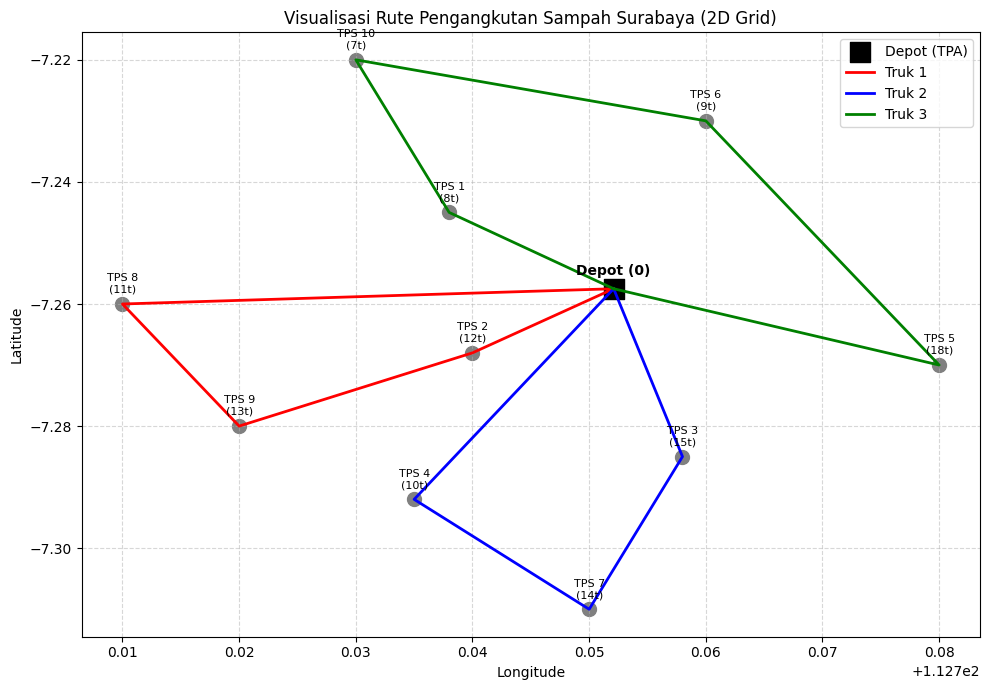

In [6]:
# Cell 6: Visualisasi Matplotlib
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot TPS Nodes
for node_id, (lat, lon) in locations.items():
    if node_id == 0:
        plt.scatter(lon, lat, c='black', s=200, marker='s', label='Depot (TPA)')
        plt.annotate('Depot (0)', (lon, lat), textcoords="offset points", xytext=(0, 10), ha='center', weight='bold')
    else:
        plt.scatter(lon, lat, c='gray', s=100, marker='o')
        plt.annotate(f'TPS {node_id}\n({demands[node_id]}t)', (lon, lat), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)

# Plot Routes
for item in routes_summary:
    v_id = item['vehicle']
    route = item['route']
    color = colors[v_id % len(colors)]

    route_coords = [locations[node] for node in route]
    lons = [c[1] for c in route_coords]
    lats = [c[0] for c in route_coords]

    plt.plot(lons, lats, color=color, linewidth=2, linestyle='-', label=f'Truk {v_id + 1}')

plt.title('Visualisasi Rute Pengangkutan Sampah Surabaya (2D Grid)', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Visualisasi Interaktif Peta Surabaya (Folium)
Visualisasi di atas peta nyata kota Surabaya menggunakan library Folium.

In [7]:
# Cell 7: Visualisasi Peta Folium
surabaya_center = [-7.2650, 112.7450]
m = folium.Map(location=surabaya_center, zoom_start=13, tiles="OpenStreetMap")

# Marker Depot
folium.Marker(
    location=locations[0],
    popup="<b>Depot Utama (TPA)</b>",
    icon=folium.Icon(color='black', icon='home', prefix='fa')
).add_to(m)

# Marker TPS
for node_id in range(1, len(locations)):
    folium.CircleMarker(
        location=locations[node_id],
        radius=7,
        popup=f"<b>TPS {node_id}</b><br>Demand: {demands[node_id]} Ton",
        color='blue',
        fill=True,
        fill_color='cyan'
    ).add_to(m)

# Gambar Rute
route_colors = ['red', 'blue', 'green', 'orange', 'purple']
for item in routes_summary:
    v_id = item['vehicle']
    route = item['route']
    points = [locations[node] for node in route]

    folium.PolyLine(
        points,
        color=route_colors[v_id % len(route_colors)],
        weight=4,
        opacity=0.8,
        tooltip=f"Rute Truk {v_id + 1} ({item['distance_km']:.2f} km)"
    ).add_to(m)

m

In [8]:
# Cell 8: Dataframe Hasil Analisis
df_results = pd.DataFrame(routes_summary)
df_results['capacity'] = vehicle_capacity
df_results['utilization_%'] = (df_results['load'] / df_results['capacity'] * 100).round(2)
df_results['route_str'] = df_results['route'].apply(lambda x: " -> ".join(map(str, x)))

df_display = df_results[['vehicle', 'route_str', 'load', 'capacity', 'utilization_%', 'distance_km']]
df_display.columns = ['ID Truk', 'Urutan Rute', 'Muatan (Ton)', 'Kapasitas (Ton)', 'Utilisasi (%)', 'Jarak (km)']

print("--- REKAPITULASI KINERJA ARMADA ---")
print(df_display.to_string(index=False))

avg_utilization = df_results['utilization_%'].mean()
print(f"\nRata-rata Utilisasi Truk : {avg_utilization:.2f}%")

--- REKAPITULASI KINERJA ARMADA ---
 ID Truk                 Urutan Rute  Muatan (Ton)  Kapasitas (Ton)  Utilisasi (%)  Jarak (km)
       0       0 -> 2 -> 9 -> 8 -> 0            36               45          80.00      11.485
       1       0 -> 4 -> 7 -> 3 -> 0            39               45          86.67      12.912
       2 0 -> 5 -> 6 -> 10 -> 1 -> 0            42               45          93.33      16.832

Rata-rata Utilisasi Truk : 86.67%


## 8. Eksperimen: Analisis Sensitivitas Jumlah Kendaraan
Melihat dampak perubahan jumlah kendaraan terhadap total jarak tempuh sistem.

In [9]:
# Cell 9: Sensitivitas Jumlah Kendaraan
def run_experiment(v_count):
    data = create_data_model()
    data['num_vehicles'] = v_count
    data['vehicle_capacities'] = [vehicle_capacity] * v_count

    manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']), v_count, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_idx, to_idx):
        return data['distance_matrix'][manager.IndexToNode(from_idx)][manager.IndexToNode(to_idx)]

    def demand_callback(from_idx):
        return data['demands'][manager.IndexToNode(from_idx)]

    transit_idx = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    demand_idx = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(demand_idx, 0, data['vehicle_capacities'], True, 'Capacity')

    search_params = pywrapcp.DefaultRoutingSearchParameters()
    search_params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC

    sol = routing.SolveWithParameters(search_params)
    if not sol:
        return None, "Infeasible"

    total_dist = 0
    for v in range(v_count):
        idx = routing.Start(v)
        while not routing.IsEnd(idx):
            prev = idx
            idx = sol.Value(routing.NextVar(idx))
            total_dist += routing.GetArcCostForVehicle(prev, idx, v)

    return total_dist / 1000.0, "Success"

print("--- EKSPERIMEN JUMLAH KENDARAAN ---")
for v_num in [2, 3, 4, 5]:
    total_dist, status = run_experiment(v_num)
    if status == "Success":
        print(f"Jumlah Truk = {v_num} | Total Jarak Tempuh = {total_dist:.2f} km")
    else:
        print(f"Jumlah Truk = {v_num} | Tidak Cukup Kapasitas (Infeasible)")

--- EKSPERIMEN JUMLAH KENDARAAN ---
Jumlah Truk = 2 | Tidak Cukup Kapasitas (Infeasible)
Jumlah Truk = 3 | Total Jarak Tempuh = 41.23 km
Jumlah Truk = 4 | Total Jarak Tempuh = 41.23 km
Jumlah Truk = 5 | Total Jarak Tempuh = 41.23 km
